# LLM Evaluation on Bug Triage

Walkthrough notebook for all 8 pipeline steps.

**Three questions answered:**
1. What themes do bugs repeatedly report? (unsupervised clustering)
2. Can a new bug automatically find its duplicate? (semantic dedup, hit@k / MRR)
3. Are LLM-extracted fields trustworthy? (self-correcting agent + LLM-as-judge, Cohen kappa)

Set `OPENAI_API_KEY` in `.env` before running steps 2-6.

In [1]:
import os, sys
# Add project root so that pipeline.py is importable when kernel cwd is notebooks/
_root = os.path.dirname(os.path.abspath('')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
if _root not in sys.path:
    sys.path.insert(0, _root)
os.chdir(_root)  # also change cwd so relative asset paths (e.g. assets/) resolve correctly
os.environ.setdefault('MPLCONFIGDIR', '/tmp/mpl')
import matplotlib.pyplot as plt
%matplotlib inline

# Auto-reload pipeline.py on every cell run, so edits to the module take
# effect without restarting the kernel.
%load_ext autoreload
%autoreload 2

import pipeline
from pipeline import (
    step1_load, step2_embed, step3_cluster, step4_topic_stats,
    step5_extract, step6_kappa, step7_dedup, step8_readout,
)

# Set SAMPLE=True for a quick smoke-test (fewer bugs, lower API cost)
SAMPLE = False
print('setup ok')

setup ok


## Step 1 - Load corpus

`bugs.csv`: one row per bug (id, component, severity, summary, description, role).

`dup_pairs.csv`: 4,987 hard-label pairs (dup_id, master_id) used for dedup evaluation in Step 7.

In [2]:
bugs, pairs = step1_load()

if SAMPLE:
    bugs  = bugs.sample(2000, random_state=42).reset_index(drop=True)
    pairs = pairs[pairs['dup_id'].isin(bugs['id']) &
                  pairs['master_id'].isin(bugs['id'])]

bugs[['id', 'component', 'role', 'summary']].head(3)

[load] bugs=13,019  dup_pairs=4,987  masters=3,549
[load] roles: {'dup': 5000, 'corpus': 4745, 'master': 3274}
[load] description coverage: 93.3%  median desc words: 91


,id,component,role,summary
0,11040,Filters,master,"Allow filters to control biff UI (i.e. only notify me of ""important"" messages)"
1,12306,Backend,master,Message notes/annotations
2,18764,Networking,master,Full rfc2557 MHTML multipart/related support in BROWSER


## Step 2 - Embed into ChromaDB (cached)

Every bug text is embedded with `text-embedding-3-small` into a local ChromaDB.
Re-running costs nothing: already-embedded bugs are skipped automatically.

The same vector store is reused by the dedup retrieval (Step 7) and the agent tools (Step 5).

In [3]:
col = step2_embed(bugs)
print(f'ChromaDB collection size: {col.count():,}')

[embed] all 13,019 bugs already cached in ChromaDB — skipping
ChromaDB collection size: 13,019


## Step 3 - Cluster topics

KMeans is fit on all embeddings. Optimal k is selected by silhouette score on a 3,000-bug
sample. Each cluster is named by GPT-4o from 10 representative summaries.

Note: silhouette is low because duplicate bugs embed close to their master
(the retrieval signal), blurring global cluster geometry. Low silhouette != no
semantic structure: duplicate pairs still land in the same cluster at many times
the random baseline rate.

In [4]:
bugs = step3_cluster(bugs, col)
bugs['cluster_theme'].value_counts().head(12)

[cluster]   k= 8  silhouette=0.026


[cluster]   k=10  silhouette=0.028


[cluster]   k=12  silhouette=0.025


[cluster]   k=14  silhouette=0.031


[cluster]   k=16  silhouette=0.032


...

  14 ( 869) -> 'CSS Parsing Issues'


  15 ( 688) -> 'Vertical tabs issues'


  16 ( 981) -> 'UI Display Issues'


  17 ( 503) -> 'WebGPU Graphics Issues'


cluster_theme
Firefox performance issues      1266
Security Validation Issues      1098
UI Display Issues                981
Single tracking bug              968
WPT Sync Updates                 957
Inbox display issues             917
CSS Parsing Issues               869
UI/UX Menu Updates               835
View Manager Assertions          806
Address Bar Focus                743
JavaScript Engine Assertions     715
Vertical tabs issues             688
Name: count, dtype: int64

### Cluster quality: duplicate same-cluster rate vs. random baseline

In [5]:
import numpy as np

id2cluster = dict(zip(bugs['id'].astype(str), bugs['cluster_theme'].fillna('')))
id2comp    = dict(zip(bugs['id'].astype(str), bugs['component'].astype(str)))
valid_pairs = [(str(d), str(m)) for d, m in
               zip(pairs['dup_id'], pairs['master_id'])
               if str(d) in id2cluster and str(m) in id2cluster]

sc = sum(id2cluster[d] == id2cluster[m] for d, m in valid_pairs)
cc = sum(id2comp.get(d,'') == id2comp.get(m,'') for d, m in valid_pairs)
us = len(valid_pairs)

themes = bugs['cluster_theme'].dropna().tolist()
unique_themes = list(bugs['cluster_theme'].dropna().unique())
counts = np.array([themes.count(t) for t in unique_themes], dtype=float)
frac = counts / counts.sum()
rand_same = float((frac ** 2).sum())

same_cluster_rate = sc / us
print(f'Usable dup pairs : {us:,}')
print(f'  Same-cluster rate : {same_cluster_rate:.1%}  (random baseline {rand_same:.1%},  lift ×{same_cluster_rate/rand_same:.0f})')
print(f'  Same-component rate: {cc/us:.1%}   (structured-field reference)')
print(f'→ silhouette is low, but same-cluster rate is {same_cluster_rate/rand_same:.0f}× random: weak geometry ≠ no semantic structure.')

Usable dup pairs : 4,987
  Same-cluster rate : 71.9%  (random baseline 6.5%,  lift ×11)
  Same-component rate: 64.7%   (structured-field reference)
→ silhouette is low, but same-cluster rate is 11× random: weak geometry ≠ no semantic structure.


## Step 4 - Topic prevalence with Wilson confidence intervals

Reporting a topic share without uncertainty is statistically incomplete.
Wilson CIs are more accurate than the normal approximation near 0 and 1
and are guaranteed to stay inside [0, 1].

In [6]:
topic_df = step4_topic_stats(bugs)
topic_df.head(3)

[topic_stats] N=13,019  95% Wilson CI:
  Firefox performance issues          9.72%  [9.23%, 10.25%]  (n=1266)
  Security Validation Issues          8.43%  [7.97%, 8.92%]  (n=1098)
  UI Display Issues                   7.54%  [7.09%, 8.00%]  (n=981)
  Single tracking bug                 7.44%  [7.00%, 7.90%]  (n=968)
  WPT Sync Updates                    7.35%  [6.91%, 7.81%]  (n=957)
  Inbox display issues                7.04%  [6.62%, 7.50%]  (n=917)
  CSS Parsing Issues                  6.67%  [6.26%, 7.12%]  (n=869)
  UI/UX Menu Updates                  6.41%  [6.01%, 6.85%]  (n=835)
  View Manager Assertions             6.19%  [5.79%, 6.62%]  (n=806)
  Address Bar Focus                   5.71%  [5.32%, 6.12%]  (n=743)
  JavaScript Engine Assertions        5.49%  [5.11%, 5.90%]  (n=715)
  Vertical tabs issues                5.28%  [4.91%, 5.68%]  (n=688)


[topic_stats] saved topic_prevalence.png


,theme,count,share,ci_lo,ci_hi
0,Firefox performance issues,1266,0.097242,0.092271,0.102451
1,Security Validation Issues,1098,0.084338,0.079686,0.089235
2,UI Display Issues,981,0.075351,0.070941,0.080012


## Step 5 - Extraction agent (LangGraph + MCP)

The agent extracts `{area, severity, kind}` for each bug in a 50-bug sample.

Graph layout:
```
                         START
                           │
                           ▼
              ┌──────► supervisor ──► FINISH ──► END
              │  （decides which to call）
              │            │ research / extract / critique / FINISH
              │   ┌────────┼───────────┐
              │   ▼        ▼           ▼
              │ researcher extractor  critic
              │ (ReAct) (JSON out)  (schema+faithfulness)
              │   │ ▲        │          │
              │   ▼ │        │          │
              │  tools       │          │
              └───┴──────────┴──────────┘
                （all workers return to supervisor）
```

- supervisor: only branching point; routes dynamically based on state
- researcher: multi-hop tool loop (search_similar_bugs / read_bug / component_prior)
- extractor: produces JSON from bug text + evidence
- critic: schema check then LLM-as-judge faithfulness check

MCP grounding: field catalog (definitions + enums) served by `mcp_server.py`.

Cost: ~300 OpenAI API calls for 50 bugs. Set SAMPLE=True to reduce to 10 bugs.

In [7]:
import pipeline
pipeline.EXTRACT_N = 10 if SAMPLE else 50

extract_df = step5_extract(bugs, col)
extract_df[['id', 'component', 'llm_area', 'llm_area_comp',
            'llm_severity', 'llm_kind', 'llm_dup_ids',
            '_steps', '_ok', '_traj']].head()

[mcp] catalog loaded: ['area', 'severity', 'kind']  |  taxonomy: 281 components


[agent] compiled: __start__ / supervisor / researcher / extractor / critic / __end__


[extract]   processed 15/50


[extract]   processed 30/50


  [rate limit/researcher] waiting 5s …


...

  [rate limit] waiting 5s before retry 1/6 …


[extract]   processed 45/50


[extract]   processed 50/50


[extract] valid yield: first-pass 50.0% -> after critique-retry 50.0% (self-correction +0.0%)
[extract] mean supervisor steps 6.7 | 54% solved with ZERO retrieval
[extract] dedup flagged 30/50 bugs (sim ≥ 0.75)


,id,component,llm_area,llm_area_comp,llm_severity,llm_kind,llm_dup_ids,_steps,_ok,_traj
0,764076,Layout: Scrolling and Overflow,Layout,Layout,low,ui,2027840,11,False,extract → critique → extract → critique → extract → critique → research → research → research → ...
1,354493,Networking,Networking,Networking,med,security,,3,True,extract → critique → FINISH
2,2022394,Storage: localStorage & sessionStorage,Storage,Storage,high,security,,3,True,extract → critique → FINISH
3,1983429,Mail Window Front End,Mail Window Front End,Mail Window Front End,high,ui,"2039936,1944442",3,True,extract → critique → FINISH
4,1918296,OS Integration,OS Integration,OS Integration,low,ui,1977643,3,True,extract → critique → FINISH


## Step 6 - Auto-rater x Cohen kappa

Cohen kappa between LLM extractions and human labels (human_labels.csv).
Kappa calibrates how much to trust the LLM-as-judge agreement rate.

The trajectory chart shows many different paths to FINISH -- evidence
this is a real agent, not a fixed workflow.

In [8]:
kappa_results = step6_kappa(extract_df)
print(kappa_results)

[kappa] saved agent_trajectories.png


[kappa] labeled rows: 50 total, 46 used for κ (4 held out as few-shot anchors)
[kappa] judge model: gpt-4o | threshold: 5
[kappa] Cohen's κ (judge vs human) = 0.502
confusion (rows=human, cols=judge):
 [[ 4  1]
 [ 5 36]]
judge good=37/46 (80%) | human good=41/46 (89%)
{'kappa': 0.5018050541516246, 'eval_df':          id                               component  \
0    764076          Layout: Scrolling and Overflow   
1    354493                              Networking   
2   2022394  Storage: localStorage & sessionStorage   
3   1983429                   Mail Window Front End   
4   1918296                          OS Integration   
5   2050964                         DOM: Navigation   
6   1998224                          Tabbed Browser   
7   2037402                             Settings UI   
8   2043898                  Layout: Text and Fonts   
9   2041280                             Address Bar   
10  1978660                             Address Bar   
11  2036504                   

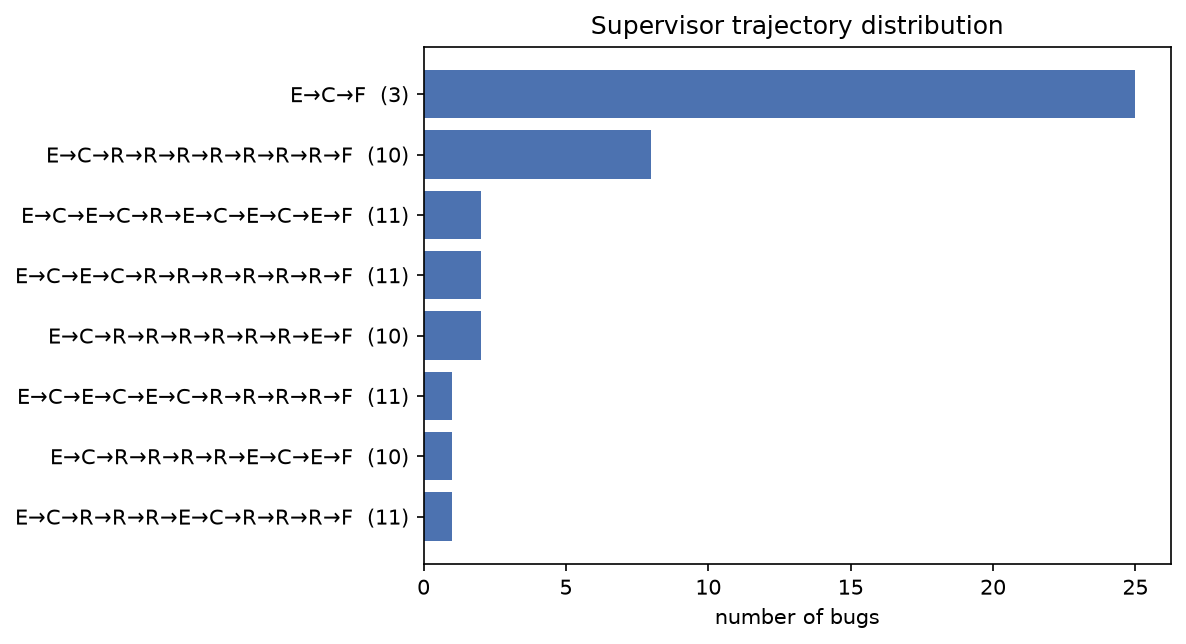

In [9]:
import os
from IPython.display import Image, display
_img = os.path.join(os.path.dirname(os.path.abspath('.')), 'llm-eval-bug-triage', 'assets', 'agent_trajectories.png')
for _candidate in [_img, '../assets/agent_trajectories.png', 'assets/agent_trajectories.png']:
    if os.path.exists(_candidate):
        display(Image(_candidate))
        break

## Step 7 - Dedup retrieval evaluation (hit@k / MRR)

For each of the duplicate bugs, query ChromaDB for top-10 similar bugs
and check whether the correct master appears in the results.

- **hit@k**: fraction of queries where the master is in the top-k results
- **MRR** (Mean Reciprocal Rank): average of 1 / rank-of-correct-master

The headline metrics are global averages. The **slice diagnostics** below break these down by cluster theme and by same-component vs cross-component pairs, revealing *where* the retrieval fails — matching the analysis in `development.ipynb` Cell 30.

In [10]:
dedup_metrics = step7_dedup(bugs, pairs, col)
dedup_metrics

[dedup] evaluating 4,987/4,987 pairs (both dup and master embedded)


[dedup]   1,000/4,987


[dedup]   2,000/4,987


[dedup]   3,000/4,987


[dedup]   4,000/4,987


[dedup]   4,987/4,987
[dedup] hit@1=0.362  hit@5=0.594  hit@10=0.667  MRR=0.459
[dedup] slice by theme (n≥50, 16 themes, Hit@10 asc)
  Hardest (bottom 3):
    IP Protection Updates               Hit@10=0.42  MRR=0.32  n=50
    UI/UX Menu Updates                  Hit@10=0.52  MRR=0.35  n=332
    Security Validation Issues          Hit@10=0.52  MRR=0.36  n=386
  Easiest (top 3):
    Single tracking bug                 Hit@10=0.74  MRR=0.57  n=347
    Firefox performance issues          Hit@10=0.75  MRR=0.52  n=570
    Address Bar Focus                   Hit@10=0.81  MRR=0.56  n=312

[dedup] same-component vs cross-component:
  same-component    Hit@10=0.72  MRR=0.51  n=3,225 (65%)
  cross-component   Hit@10=0.57  MRR=0.37  n=1,762 (35%)


[dedup] saved assets/dedup_slice.png


{'hit@1': 0.3619410467214758,
 'hit@5': 0.5939442550631642,
 'hit@10': 0.6665329857629838,
 'mrr': 0.4590451045734776,
 '_slice_by_theme': [('IP Protection Updates', 0.42, 0.32299999999999995, 50),
  ('UI/UX Menu Updates', 0.5150602409638554, 0.34773857334098296, 332),
  ('Security Validation Issues', 0.5155440414507773, 0.36055082654823584, 386),
  ('WebGPU Graphics Issues', 0.5454545454545454, 0.40165945165945177, 176),
  ('CSS Parsing Issues', 0.5929203539823009, 0.4269958327480451, 339),
  ('Vertical tabs issues', 0.6198979591836735, 0.3842160673793328, 392),
  ('New Tab Widgets', 0.6533333333333333, 0.46507407407407414, 75),
  ('View Manager Assertions', 0.6608478802992519, 0.45218402406681696, 401),
  ('PDF.js Version Updates', 0.706081081081081, 0.4701469326469326, 296),
  ('JavaScript Engine Assertions',
   0.7077922077922078,
   0.5571866625438054,
   154),
  ('Smart Window Issues', 0.7096774193548387, 0.488175243215566, 124),
  ('UI Display Issues', 0.7116564417177914, 0.4708

### Step 7 supplement · Slice diagnostics

The headline hit@10 is a global average — engineering-wise we care more about *where it fails*.
Using the cluster themes from Step 3 we group every duplicate pair by its master's theme and
also split by same-component vs cross-component, pinpointing the ceiling on retrieval accuracy.

Slice by theme (n≥50, 16 themes, Hit@10 ascending):

  Theme                               Hit@10     MRR      n
  ----------------------------------------------------------
  IP Protection Updates                 0.42    0.32     50
  UI/UX Menu Updates                    0.52    0.35    332
  Security Validation Issues            0.52    0.36    386
  WebGPU Graphics Issues                0.55    0.40    176
  CSS Parsing Issues                    0.59    0.43    339
  Vertical tabs issues                  0.62    0.38    392
  New Tab Widgets                       0.65    0.47     75
  View Manager Assertions               0.66    0.45    401
  PDF.js Version Updates                0.71    0.47    296
  JavaScript Engine Assertions          0.71    0.56    154
  Smart Window Issues                   0.71    0.49    124
  UI Display Issues                     0.71    0.47    489
  Inbox display issues                  0.72    0.47    522
  Single tracking bug                   0.74  

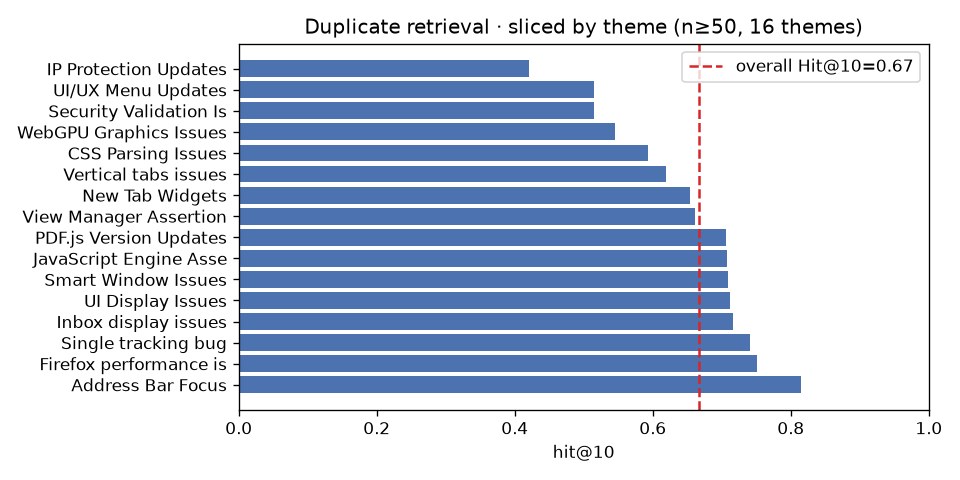

In [11]:
from IPython.display import Image, display
import os

# ---- Print slice table ----
rows_sl = dedup_metrics.get("_slice_by_theme", [])
by_cross = dedup_metrics.get("_slice_by_cross", {})

if rows_sl:
    print(f"Slice by theme (n≥50, {len(rows_sl)} themes, Hit@10 ascending):\n")
    print(f"  {'Theme':<34}  {'Hit@10':>6}  {'MRR':>6}  {'n':>5}")
    print("  " + "-" * 58)
    for name_, p, r, cnt in rows_sl:
        print(f"  {name_[:34]:<34}  {p:>6.2f}  {r:>6.2f}  {cnt:>5}")
else:
    print("No slice data available (cluster_theme column missing or no pairs evaluated).")

if by_cross and all(by_cross.get(k, [0,0,0])[2] > 0 for k in [True, False]):
    _tot = sum(v[2] for v in by_cross.values())
    print("\nSame-component vs cross-component:")
    for key, nm in [(True, "same-component"), (False, "cross-component")]:
        h, r, cnt = by_cross[key]
        print(f"  {nm:<16}  Hit@10={h/cnt:.2f}  MRR={r/cnt:.2f}  n={cnt:,} ({cnt/_tot:.0%})")

# ---- Show chart saved by pipeline ----
for _candidate in ['../assets/dedup_slice.png', 'assets/dedup_slice.png']:
    if os.path.exists(_candidate):
        display(Image(_candidate))
        break

## Step 8 - Final readout

In [12]:
step8_readout(topic_df, extract_df, kappa_results, dedup_metrics)


PIPELINE SUMMARY

-- Top 5 bug themes --
  Firefox performance issues                9.7%
  Security Validation Issues                8.4%
  UI Display Issues                         7.5%
  Single tracking bug                       7.4%
  WPT Sync Updates                          7.4%

-- Extraction agent (LLM-as-judge) --
  first-pass yield:   50.0%
  final valid yield:  50.0%
  mean steps:         6.7
  Cohen's κ (judge vs human): 0.502

-- Dedup retrieval --
  hit@1: 0.362
  hit@5: 0.594
  hit@10: 0.667
  mrr: 0.459

  Slice by theme (n≥50, 16 themes, Hit@10 asc):
    Hardest  IP Protection Updates           Hit@10=0.42  MRR=0.32
    Hardest  UI/UX Menu Updates              Hit@10=0.52  MRR=0.35
    Hardest  Security Validation Issues      Hit@10=0.52  MRR=0.36
    Easiest  Single tracking bug             Hit@10=0.74  MRR=0.57
    Easiest  Firefox performance issues      Hit@10=0.75  MRR=0.52
    Easiest  Address Bar Focus               Hit@10=0.81  MRR=0.56

  Same-component vs cr